In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.formula.api import ols
from mpl_toolkits.mplot3d import Axes3D

In [3]:
mtcars = sm.datasets.get_rdataset("mtcars").data

mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [4]:
mtcars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [5]:
mtcars.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [6]:
print("MÉDIAS")
print(mtcars.mean())

print("\nMEDIANAS")
print(mtcars.median())

print("\nDESVIO PADRÃO")
print(mtcars.std())

MÉDIAS
mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

MEDIANAS
mpg      19.200
cyl       6.000
disp    196.300
hp      123.000
drat      3.695
wt        3.325
qsec     17.710
vs        0.000
am        0.000
gear      4.000
carb      2.000
dtype: float64

DESVIO PADRÃO
mpg       6.026948
cyl       1.785922
disp    123.938694
hp       68.562868
drat      0.534679
wt        0.978457
qsec      1.786943
vs        0.504016
am        0.498991
gear      0.737804
carb      1.615200
dtype: float64


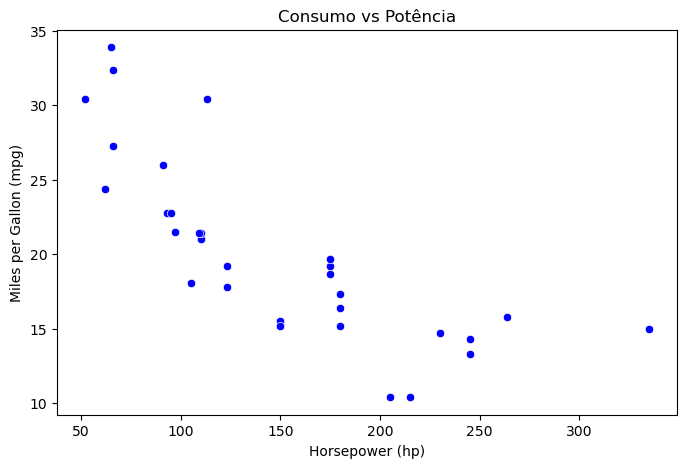

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='hp', y='mpg', data=mtcars, color='blue')

plt.title('Consumo vs Potência')
plt.xlabel('Horsepower (hp)')
plt.ylabel('Miles per Gallon (mpg)')

plt.show()

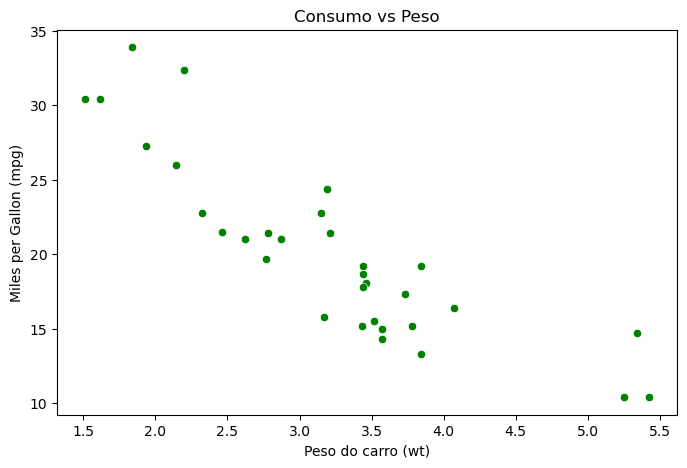

In [8]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='wt', y='mpg', data=mtcars, color='green')

plt.title('Consumo vs Peso')
plt.xlabel('Peso do carro (wt)')
plt.ylabel('Miles per Gallon (mpg)')

plt.show()

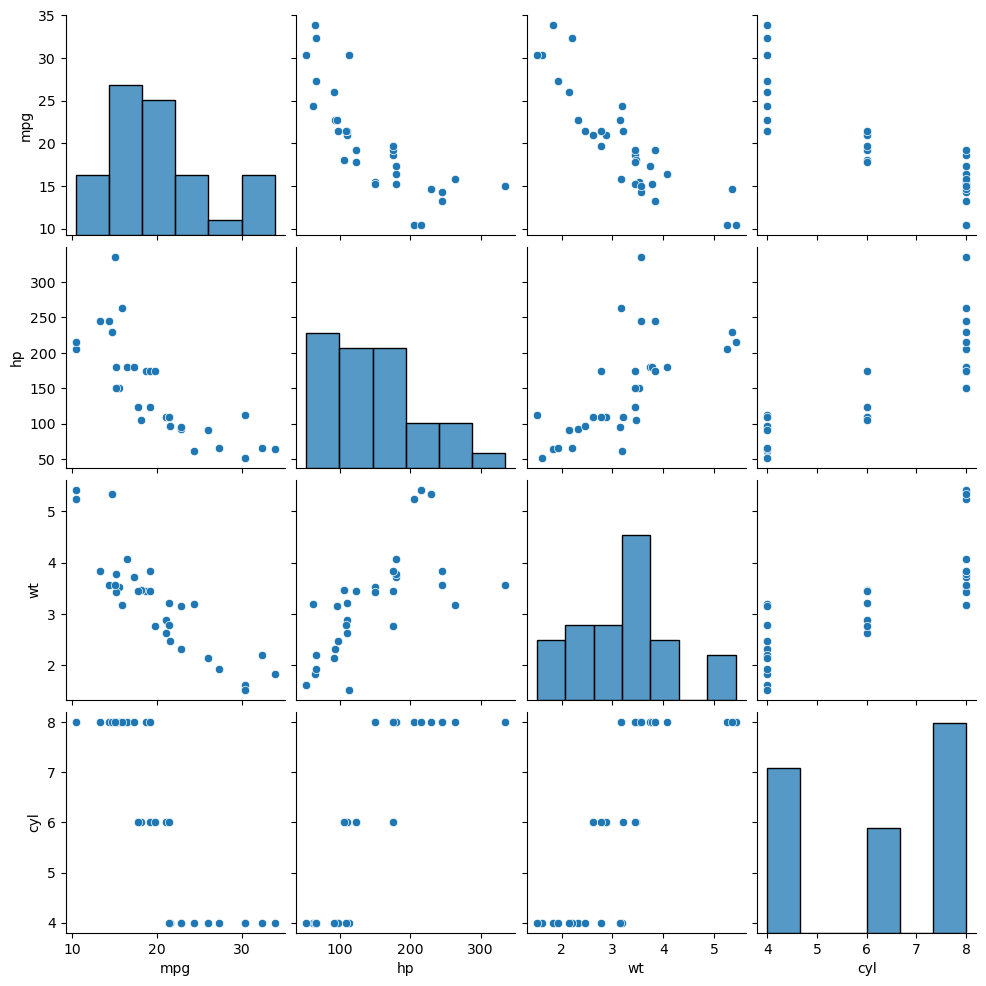

In [9]:
sns.pairplot(mtcars[['mpg', 'hp', 'wt', 'cyl']])
plt.show()

In [10]:
X = mtcars[['hp']]
y = mtcars['mpg']

modelo_simples = LinearRegression()

modelo_simples.fit(X, y)

y_pred = modelo_simples.predict(X)

print("Intercepto:", modelo_simples.intercept_)
print("Coeficiente:", modelo_simples.coef_[0])

print("R²:", r2_score(y, y_pred))

Intercepto: 30.098860539622496
Coeficiente: -0.06822827807156365
R²: 0.602437341423934


In [11]:
modelo_stats = ols('mpg ~ hp', data=mtcars).fit()

print(modelo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     45.46
Date:                Thu, 07 May 2026   Prob (F-statistic):           1.79e-07
Time:                        21:23:49   Log-Likelihood:                -87.619
No. Observations:                  32   AIC:                             179.2
Df Residuals:                      30   BIC:                             182.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.0989      1.634     18.421      0.0

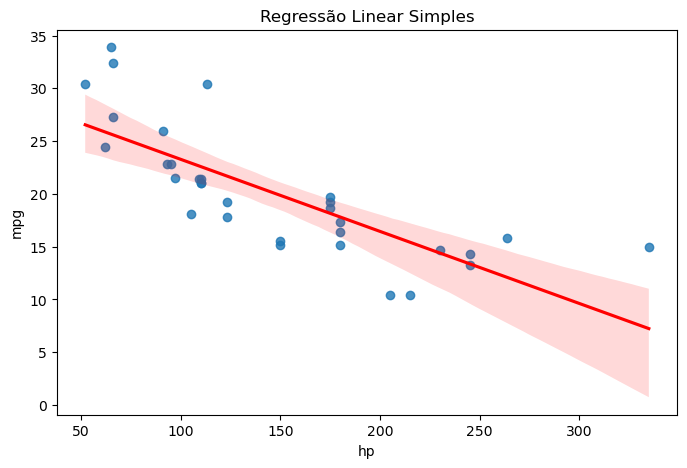

In [12]:
plt.figure(figsize=(8,5))

sns.regplot(x='hp',
            y='mpg',
            data=mtcars,
            line_kws={"color":"red"})

plt.title('Regressão Linear Simples')

plt.show()

In [14]:
X2 = mtcars[['hp', 'wt']]
y2 = mtcars['mpg']

modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X2, y2)

pred2 = modelo_multiplo.predict(X2)

print(modelo_multiplo.intercept_)
print(modelo_multiplo.coef_)
print(r2_score(y2, pred2))

37.2272701164472
[-0.03177295 -3.87783074]
0.8267854518827914


In [15]:
modelo_multiplo_stats = ols('mpg ~ hp + wt', data=mtcars).fit()

print(modelo_multiplo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Thu, 07 May 2026   Prob (F-statistic):           9.11e-12
Time:                        21:24:14   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:                      29   BIC:                             159.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2273      1.599     23.285      0.0

In [16]:
anova = sm.stats.anova_lm(modelo_stats,
                          modelo_multiplo_stats)

print(anova)

   df_resid         ssr  df_diff     ss_diff          F    Pr(>F)
0      30.0  447.674314      0.0         NaN        NaN       NaN
1      29.0  195.047755      1.0  252.626559  37.560905  0.000001


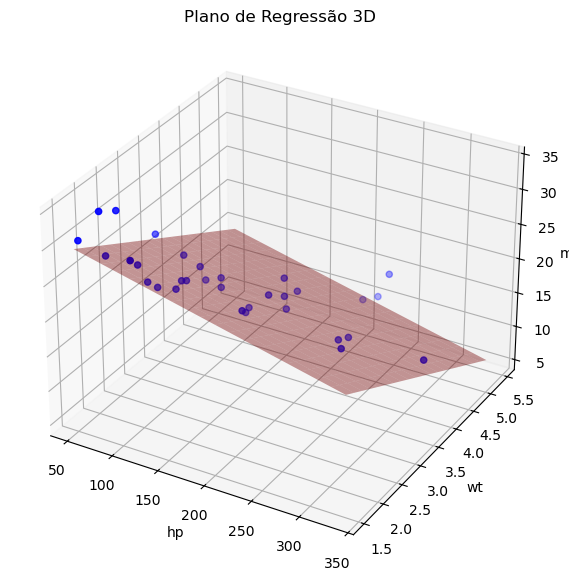

In [17]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(mtcars['hp'],
           mtcars['wt'],
           mtcars['mpg'],
           color='blue')

hp_surf, wt_surf = np.meshgrid(
    np.linspace(mtcars.hp.min(), mtcars.hp.max(), 20),
    np.linspace(mtcars.wt.min(), mtcars.wt.max(), 20)
)

mpg_surf = (
    modelo_multiplo.intercept_
    + modelo_multiplo.coef_[0] * hp_surf
    + modelo_multiplo.coef_[1] * wt_surf
)

ax.plot_surface(hp_surf,
                wt_surf,
                mpg_surf,
                color='red',
                alpha=0.4)

ax.set_xlabel('hp')
ax.set_ylabel('wt')
ax.set_zlabel('mpg')

plt.title('Plano de Regressão 3D')

plt.show()

In [18]:
residuos = y2 - pred2

print(residuos)

rownames
Mazda RX4             -2.572329
Mazda RX4 Wag         -1.583483
Datsun 710            -2.475819
Hornet 4 Drive         0.134980
Hornet Sportabout      0.372733
Valiant               -2.373816
Duster 360            -1.299042
Merc 240D              1.512933
Merc 230               0.806327
Merc 280              -0.779460
Merc 280C             -2.179460
Merc 450SE             0.674631
Merc 450SL             0.256169
Merc 450SLC           -1.649939
Cadillac Fleetwood     0.044795
Lincoln Continental    1.037267
Chrysler Imperial      5.507513
Fiat 128               5.800972
Honda Civic            1.087620
Toyota Corolla         5.853791
Toyota Corona         -3.086441
Dodge Challenger      -3.311364
AMC Javelin           -3.940979
Camaro Z28            -1.252028
Pontiac Firebird       2.443255
Fiat X1-9             -0.326653
Porsche 914-2         -0.037374
Lotus Europa           2.630231
Ford Pantera L        -0.746489
Ferrari Dino          -1.225413
Maserati Bora          2.260523

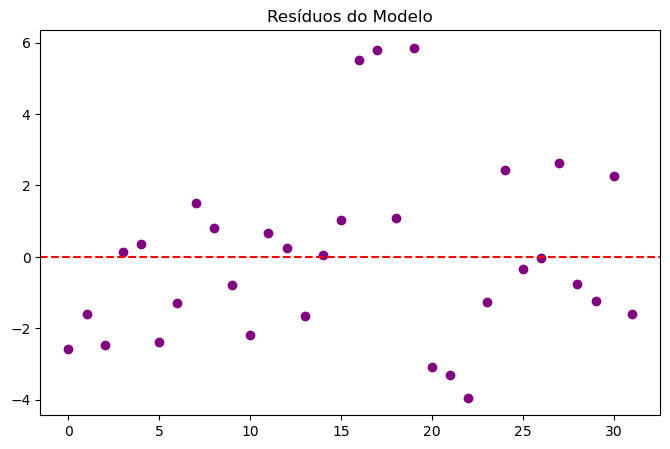

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(residuos)),
            residuos,
            color='purple')

plt.axhline(y=0,
            color='red',
            linestyle='--')

plt.title('Resíduos do Modelo')

plt.show()

In [20]:
influence = modelo_multiplo_stats.get_influence()

cooks = influence.cooks_distance[0]

print(cooks)

[1.58965233e-02 5.46477876e-03 2.07065144e-02 4.72482239e-05
 2.73618420e-04 2.15506367e-02 1.25521825e-02 1.67765016e-02
 2.18870150e-03 1.55499617e-03 1.21573675e-02 1.42300757e-03
 1.45895957e-04 6.26604928e-03 2.78668611e-05 1.78090982e-02
 4.23610902e-01 1.57426289e-01 9.37144586e-03 2.08393260e-01
 2.79198173e-02 2.08741886e-02 2.75150988e-02 9.94352707e-03
 1.44319852e-02 5.92043955e-04 5.67498567e-06 7.35398500e-02
 8.91970082e-03 5.73267216e-03 2.72039749e-01 5.60080368e-03]


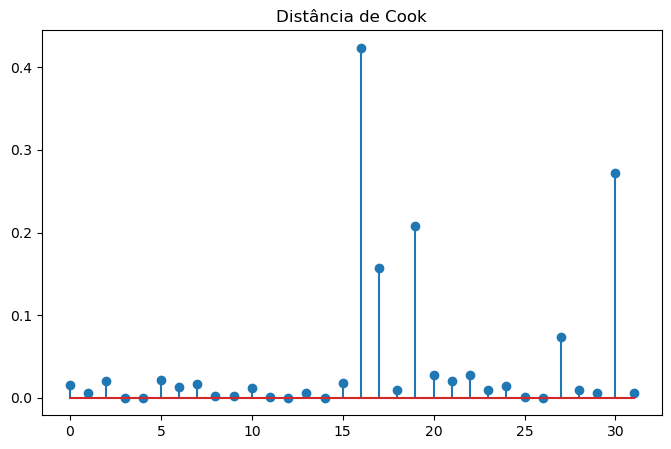

In [21]:
plt.figure(figsize=(8,5))

plt.stem(np.arange(len(cooks)),
         cooks)

plt.title("Distância de Cook")

plt.show()

1) Coeficientes negativos indicam relação inversa entre as variáveis.

2) O modelo múltiplo pode ser considerado melhor se o p-valor da ANOVA for menor que 0.05.

3) Variáveis adicionais:
- cyl
- am
- disp
- drat
- qsec

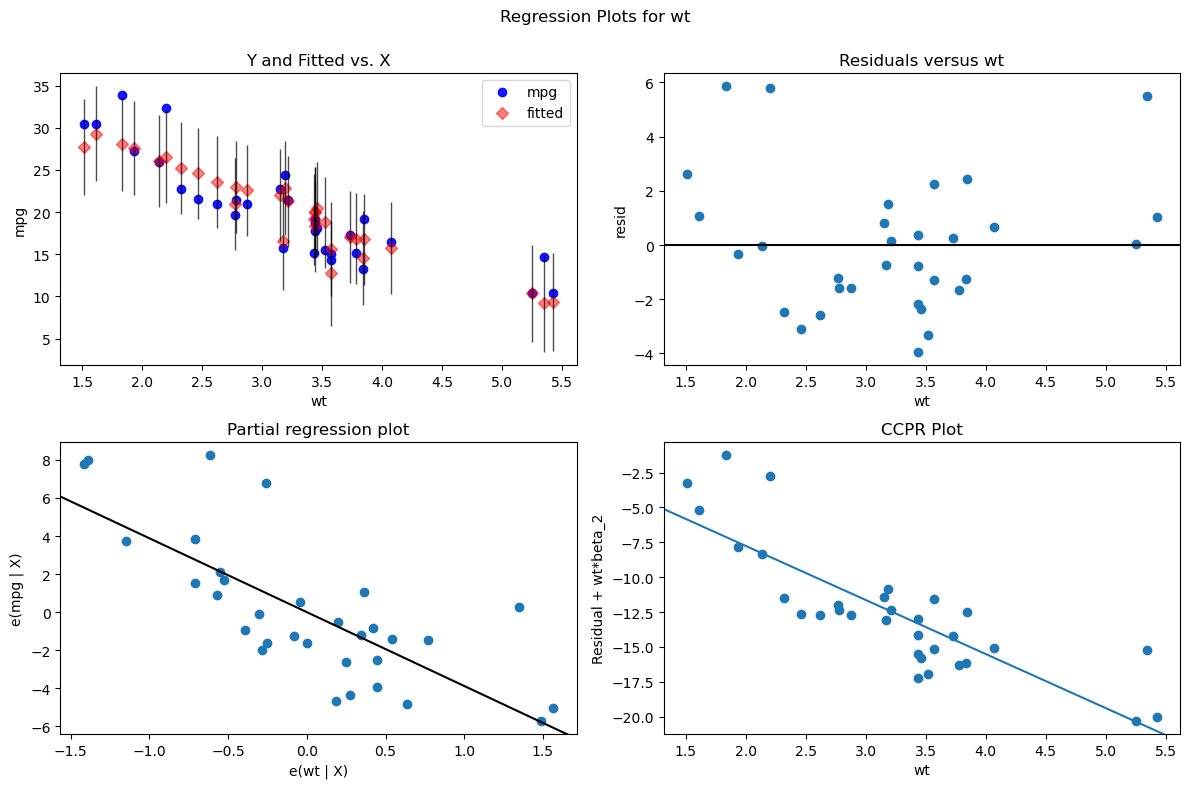

In [23]:
fig = plt.figure(figsize=(12,8))

fig = sm.graphics.plot_regress_exog(
    modelo_multiplo_stats,
    "wt",
    fig=fig
)

plt.show()

Carros mais pesados e mais potentes tendem a apresentar menor eficiência no consumo.
O modelo múltiplo apresentou melhor ajuste em relação ao modelo simples.